# PCA + HJM Yield Curve Simulator

This notebook implements a **Heath–Jarrow–Morton (HJM)** model driven by **Principal Component Analysis (PCA)** of historical US Treasury yield data.

### How it works
1. **Load & clean** the raw yield data (11 maturities: 1M → 30Y)
2. **PCA** on daily yield changes → extract Level, Slope, Curvature factors
3. **HJM simulation** → shock the current yield curve using random factor draws
4. **Generate 500 simulated yield curves**
5. **Visualise** with full fan charts, factor loadings, and distributions

---
### Requirements
```
pip install pandas numpy matplotlib scipy
```

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#05080f',
    'axes.facecolor':   '#090e1a',
    'axes.edgecolor':   '#1a2340',
    'axes.labelcolor':  '#c8d8f0',
    'xtick.color':      '#4a5a7a',
    'ytick.color':      '#4a5a7a',
    'text.color':       '#c8d8f0',
    'grid.color':       '#1a2340',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'legend.facecolor': '#090e1a',
    'legend.edgecolor': '#1a2340',
})

# Colour palette
C_SIM      = '#00c8ff'
C_CURRENT  = '#ff6b35'
C_MEAN     = '#7fff6b'
C_PC1      = '#00d4ff'
C_PC2      = '#ff6b35'
C_PC3      = '#7fff6b'

print('✓ Setup complete')

✓ Setup complete


## 2. Load & Explore Data

Place the CSV file in the same directory as this notebook, or update the path below.

In [2]:
# ── Load CSV ─────────────────────────────────────────────────────────────────
CSV_PATH = 'raw_macro_yield_dataset(in).csv'   # <-- update path if needed

df = pd.read_csv(CSV_PATH, parse_dates=['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# Maturity columns only
YIELD_COLS = [
    'Yield_1M', 'Yield_3M', 'Yield_6M', 'Yield_1Y',
    'Yield_2Y', 'Yield_3Y', 'Yield_5Y', 'Yield_7Y',
    'Yield_10Y', 'Yield_20Y', 'Yield_30Y'
]
MAT_LABELS = ['1M','3M','6M','1Y','2Y','3Y','5Y','7Y','10Y','20Y','30Y']
MATURITIES = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]  # in years

yields = df[YIELD_COLS].dropna().copy()
dates  = df.loc[yields.index, 'DATE'].values

print(f'Dataset : {len(yields):,} observations')
print(f'Period  : {dates[0][:10]} → {dates[-1][:10]}'  if isinstance(dates[0], str)
      else f'Period  : {str(dates[0])[:10]} → {str(dates[-1])[:10]}')
print(f'Maturities: {MAT_LABELS}')
yields.describe().round(3)

Dataset : 6,037 observations
Period  : 2002-01-02 → 2026-02-20
Maturities: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']


,Yield_1M,Yield_3M,Yield_6M,Yield_1Y,Yield_2Y,Yield_3Y,Yield_5Y,Yield_7Y,Yield_10Y,Yield_20Y,Yield_30Y
count,6037.000,6037.000,6037.000,6037.000,6037.000,6037.000,6037.000,6037.000,6037.000,6037.000,6037.000
mean,1.661,1.722,1.814,1.880,2.036,2.207,2.566,2.871,3.144,3.666,3.764
std,1.845,1.854,1.840,1.752,1.590,1.475,1.313,1.218,1.161,1.181,1.085
min,0.000,0.000,0.020,0.040,0.090,0.100,0.190,0.360,0.520,0.870,0.990
25%,0.070,0.100,0.150,0.250,0.600,0.920,1.510,1.900,2.180,2.660,2.940
50%,0.960,1.040,1.160,1.330,1.630,1.840,2.460,2.870,3.150,3.850,3.860
75%,2.720,3.000,3.220,3.340,3.510,3.590,3.740,3.930,4.180,4.710,4.680
max,6.020,5.630,5.610,5.490,5.290,5.260,5.230,5.290,5.440,6.050,5.920


## 3. PCA on Daily Yield Changes

In [3]:
# ── Compute daily changes ────────────────────────────────────────────────────
Y = yields.values                        # shape (N, 11)
dY = np.diff(Y, axis=0)                  # shape (N-1, 11)

mean_change = dY.mean(axis=0)            # drift term
dY_centered = dY - mean_change

# ── Covariance & eigendecomposition ─────────────────────────────────────────
cov = np.cov(dY_centered.T)              # (11, 11)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]      # columns are PCs

N_FACTORS = 3   # Level, Slope, Curvature
factors   = eigenvectors[:, :N_FACTORS]  # (11, 3)

explained_var   = eigenvalues / eigenvalues.sum() * 100
factor_stds     = (dY_centered @ factors).std(axis=0)

print('PCA Results')
print('─' * 40)
for k in range(N_FACTORS):
    label = ['Level', 'Slope', 'Curvature'][k]
    print(f'  PC{k+1} ({label:10s})  →  {explained_var[k]:.2f}% variance explained')
print(f'  Total (3 PCs)        →  {explained_var[:N_FACTORS].sum():.2f}%')
print()
print('Factor volatilities (daily bps):')
for k in range(N_FACTORS):
    print(f'  PC{k+1}: {factor_stds[k]*100:.3f} bps')

PCA Results
────────────────────────────────────────
  PC1 (Level     )  →  68.02% variance explained
  PC2 (Slope     )  →  16.25% variance explained
  PC3 (Curvature )  →  7.87% variance explained
  Total (3 PCs)        →  92.14%

Factor volatilities (daily bps):
  PC1: 14.570 bps
  PC2: 7.122 bps
  PC3: 4.955 bps


## 4. Plot Factor Loadings

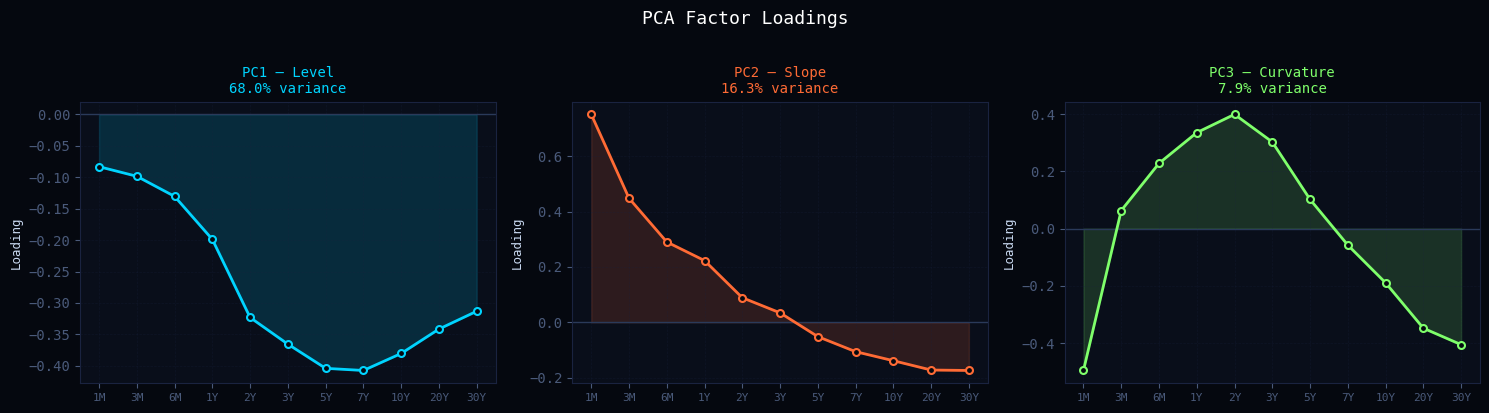

Saved → pca_factor_loadings.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PCA Factor Loadings', color='white', fontsize=13, y=1.02)

colors = [C_PC1, C_PC2, C_PC3]
names  = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']

x = np.arange(len(MAT_LABELS))

for k, ax in enumerate(axes):
    loadings = factors[:, k]
    ax.axhline(0, color='#2a3a5a', linewidth=1)
    ax.plot(x, loadings, color=colors[k], linewidth=2, marker='o',
            markersize=5, markerfacecolor='#05080f', markeredgewidth=1.5,
            markeredgecolor=colors[k])
    ax.fill_between(x, 0, loadings, alpha=0.15, color=colors[k])
    ax.set_xticks(x)
    ax.set_xticklabels(MAT_LABELS, fontsize=8)
    ax.set_title(f'{names[k]}\n{explained_var[k]:.1f}% variance',
                 color=colors[k], fontsize=10)
    ax.set_ylabel('Loading', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_factor_loadings.png', dpi=150, bbox_inches='tight',
            facecolor='#05080f')
plt.show()
print('Saved → pca_factor_loadings.png')

## 5. HJM Simulation — Generate 500 Yield Curves

Under the HJM framework each forward rate is driven by:
$$
\Delta y(T) = \mu(T) + \sum_{k=1}^{3} \sigma_k \cdot \phi_k(T) \cdot Z_k, \quad Z_k \sim \mathcal{N}(0,1)
$$
where $\phi_k(T)$ are the PCA factor loadings and $\sigma_k$ the empirical factor volatilities.

In [5]:
# ── Simulation parameters ───────────────────────────────────────────────────
N_SIM      = 500          # number of simulated curves
N_FACTORS  = 3            # PCA factors to use
VOL_SCALE  = 1.0          # volatility multiplier (1.0 = empirical)
RANDOM_SEED = 42          # for reproducibility

np.random.seed(RANDOM_SEED)

last_curve = Y[-1]        # starting point: most recent observation

# ── Simulate ────────────────────────────────────────────────────────────────
Z = np.random.randn(N_SIM, N_FACTORS)          # (500, 3) standard normals

# Scaled shocks: Z * σ_k * vol_scale, shape (500, 3)
scaled_shocks = Z * factor_stds[:N_FACTORS] * VOL_SCALE

# Project onto yield curve space: (500, 3) @ (3, 11)  →  (500, 11)
curve_changes = mean_change + scaled_shocks @ factors[:, :N_FACTORS].T

# Apply to last observed curve
sim_curves = last_curve + curve_changes        # (500, 11)

print(f'Generated {N_SIM} simulated yield curves')
print(f'Starting from: {str(dates[-1])[:10]}')
print()
print('Simulated 10Y yield statistics:')
print(f'  Current   : {last_curve[8]:.3f}%')
print(f'  Sim Mean  : {sim_curves[:, 8].mean():.3f}%')
print(f'  Sim Std   : {sim_curves[:, 8].std():.3f}%')
print(f'  P10–P90   : {np.percentile(sim_curves[:, 8], 10):.3f}% – {np.percentile(sim_curves[:, 8], 90):.3f}%')

Generated 500 simulated yield curves
Starting from: 2026-02-20

Simulated 10Y yield statistics:
  Current   : 4.080%
  Sim Mean  : 4.073%
  Sim Std   : 0.054%
  P10–P90   : 4.003% – 4.142%


## 6. Main Visualisation — All 500 Simulated Curves

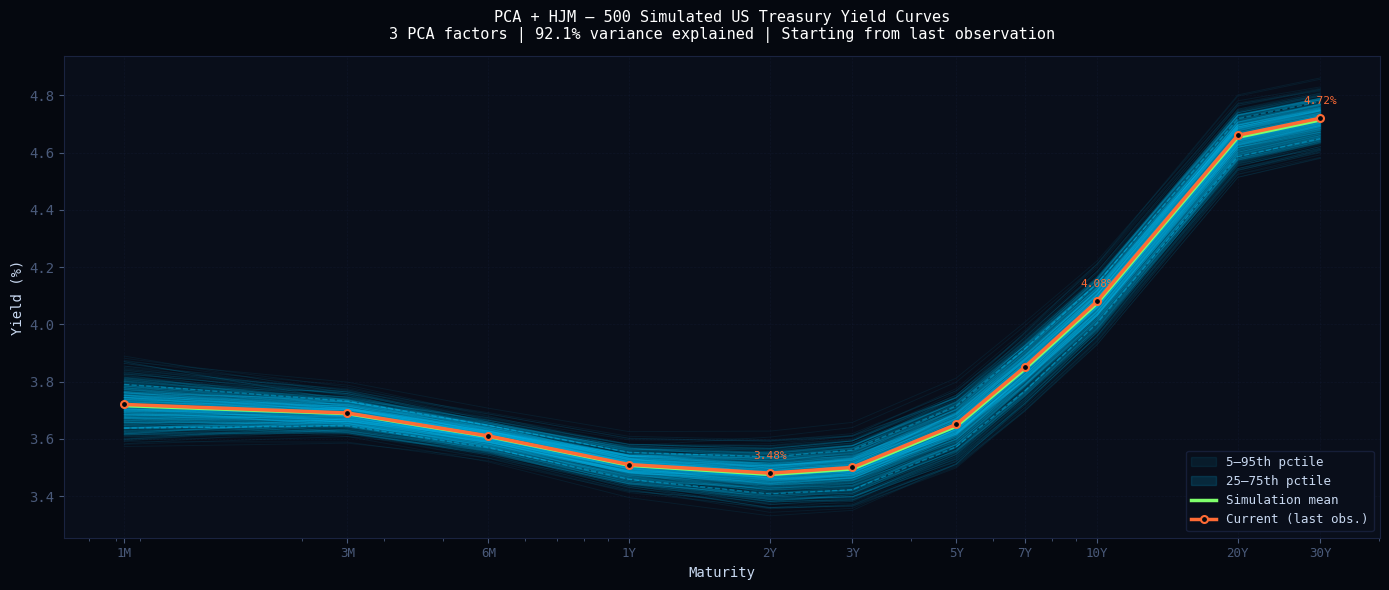

Saved → hjm_simulated_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#05080f')

x = np.array(MATURITIES)

# ── Simulated paths ─────────────────────────────────────────────────────────
for curve in sim_curves:
    ax.plot(x, curve, color=C_SIM, alpha=0.07, linewidth=0.7)

# ── Percentile bands ────────────────────────────────────────────────────────
pct = {p: np.percentile(sim_curves, p, axis=0) for p in [5, 10, 25, 50, 75, 90, 95]}

ax.fill_between(x, pct[5],  pct[95], color=C_SIM, alpha=0.08, label='5–95th pctile')
ax.fill_between(x, pct[25], pct[75], color=C_SIM, alpha=0.15, label='25–75th pctile')
ax.plot(x, pct[10], color=C_SIM, alpha=0.4, linewidth=1, linestyle='--')
ax.plot(x, pct[90], color=C_SIM, alpha=0.4, linewidth=1, linestyle='--')

# ── Simulation mean ─────────────────────────────────────────────────────────
ax.plot(x, sim_curves.mean(axis=0), color=C_MEAN, linewidth=2.5,
        label='Simulation mean', zorder=5)

# ── Current curve ───────────────────────────────────────────────────────────
ax.plot(x, last_curve, color=C_CURRENT, linewidth=2.5, zorder=6,
        marker='o', markersize=5, markerfacecolor='#05080f',
        markeredgewidth=1.5, label='Current (last obs.)')

# ── Labels ──────────────────────────────────────────────────────────────────
ax.set_xscale('log')
ax.set_xticks(MATURITIES)
ax.set_xticklabels(MAT_LABELS, fontsize=9)
ax.set_xlabel('Maturity', fontsize=10)
ax.set_ylabel('Yield (%)', fontsize=10)
ax.set_title(f'PCA + HJM — {N_SIM} Simulated US Treasury Yield Curves\n'
             f'3 PCA factors | {explained_var[:3].sum():.1f}% variance explained | '
             f'Starting from last observation',
             color='white', fontsize=11, pad=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower right')

# Annotate current key points
for i, (mat, label, yld) in enumerate(zip(MATURITIES, MAT_LABELS, last_curve)):
    if label in ['2Y', '10Y', '30Y']:
        ax.annotate(f'{yld:.2f}%', (mat, yld),
                    textcoords='offset points', xytext=(0, 10),
                    color=C_CURRENT, fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('hjm_simulated_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#05080f')
plt.show()
print('Saved → hjm_simulated_curves.png')

## 7. Full Dashboard — 4-Panel Summary

ValueError: Invalid RGBA argument: 'rgba(0,200,255,0.6)'

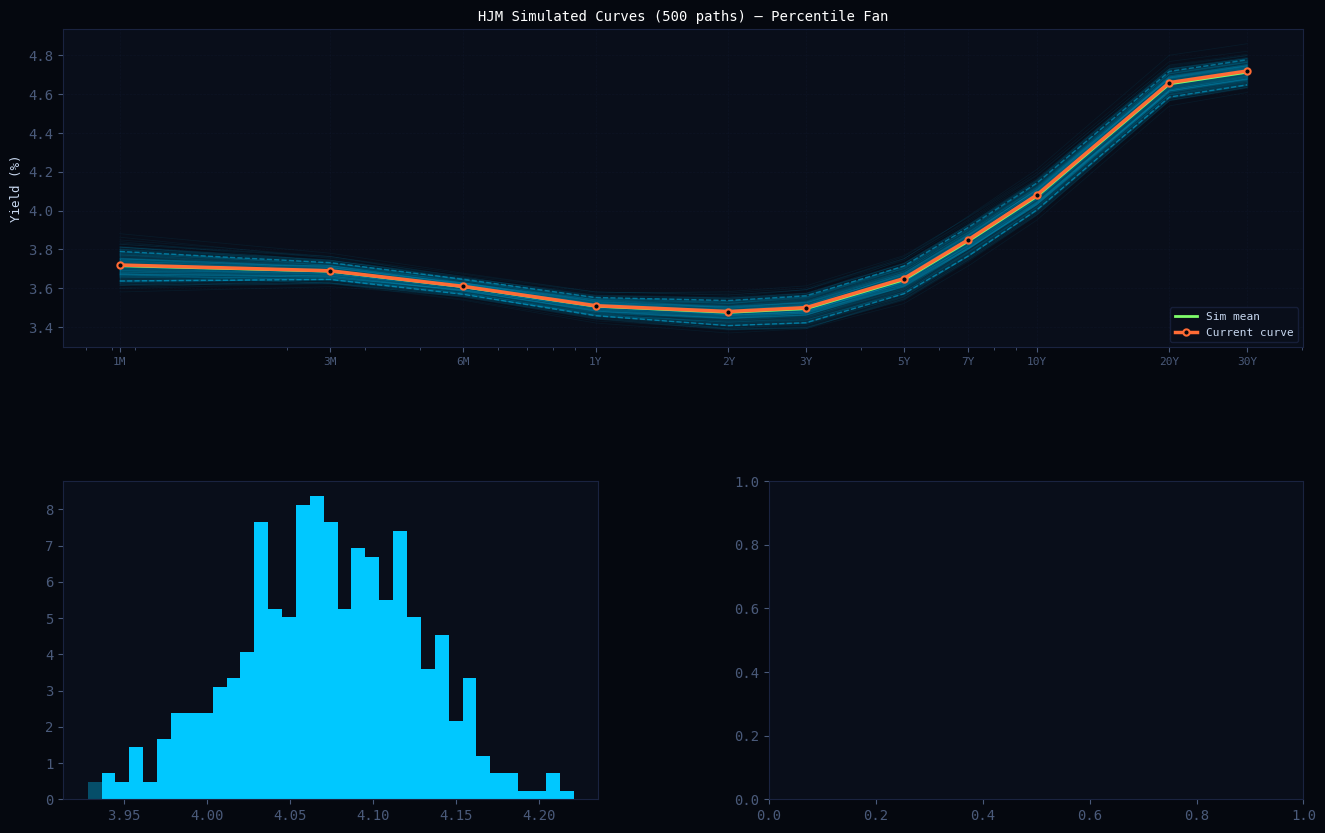

In [7]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#05080f')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

x = np.array(MATURITIES)

# ── Panel 1: Fan chart ───────────────────────────────────────────────────────
for curve in sim_curves[::5]:  # subsample for speed
    ax1.plot(x, curve, color=C_SIM, alpha=0.06, linewidth=0.6)

ax1.fill_between(x, pct[5],  pct[95], color=C_SIM, alpha=0.08)
ax1.fill_between(x, pct[10], pct[90], color=C_SIM, alpha=0.10)
ax1.fill_between(x, pct[25], pct[75], color=C_SIM, alpha=0.15)
ax1.plot(x, pct[10], '--', color=C_SIM, alpha=0.45, linewidth=1.0)
ax1.plot(x, pct[90], '--', color=C_SIM, alpha=0.45, linewidth=1.0)
ax1.plot(x, sim_curves.mean(axis=0), color=C_MEAN, linewidth=2, label='Sim mean')
ax1.plot(x, last_curve, color=C_CURRENT, linewidth=2.5,
         marker='o', markersize=4.5, markerfacecolor='#05080f',
         markeredgewidth=1.5, label='Current curve')

ax1.set_xscale('log')
ax1.set_xticks(MATURITIES); ax1.set_xticklabels(MAT_LABELS, fontsize=8)
ax1.set_ylabel('Yield (%)', fontsize=9)
ax1.set_title(f'HJM Simulated Curves ({N_SIM} paths) — Percentile Fan',
              color='white', fontsize=10)
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.25)

# ── Panel 2: 10Y distribution ────────────────────────────────────────────────
vals_10y = sim_curves[:, 8]
ax2.hist(vals_10y, bins=35, color=C_SIM, alpha=0.35, edgecolor='rgba(0,200,255,0.6)',
         linewidth=0.5, density=True)

# Fit normal
mu, sigma = norm.fit(vals_10y)
x_fit = np.linspace(vals_10y.min(), vals_10y.max(), 200)
ax2.plot(x_fit, norm.pdf(x_fit, mu, sigma), color=C_MEAN, linewidth=1.5,
         label=f'N({mu:.3f}, {sigma:.3f})')
ax2.axvline(last_curve[8], color=C_CURRENT, linewidth=2, linestyle='--',
            label=f'Current: {last_curve[8]:.2f}%')
ax2.axvline(mu, color=C_MEAN, linewidth=1.5, linestyle='--',
            label=f'Sim mean: {mu:.2f}%')

ax2.set_xlabel('10Y Yield (%)', fontsize=9)
ax2.set_ylabel('Density', fontsize=9)
ax2.set_title('10Y Yield Distribution', color='white', fontsize=10)
ax2.legend(fontsize=7.5)
ax2.grid(True, alpha=0.25)

# ── Panel 3: 2Y–10Y spread distribution ─────────────────────────────────────
spread_sim = (sim_curves[:, 8] - sim_curves[:, 4]) * 100  # bps
spread_now = (last_curve[8] - last_curve[4]) * 100

ax3.hist(spread_sim, bins=35, color='#ff6b35', alpha=0.3,
         edgecolor='rgba(255,107,53,0.6)', linewidth=0.5, density=True)

mu_s, sig_s = norm.fit(spread_sim)
x_s = np.linspace(spread_sim.min(), spread_sim.max(), 200)
ax3.plot(x_s, norm.pdf(x_s, mu_s, sig_s), color=C_MEAN, linewidth=1.5)
ax3.axvline(spread_now, color=C_CURRENT, linewidth=2, linestyle='--',
            label=f'Current: {spread_now:.1f} bps')
ax3.axvline(mu_s, color=C_MEAN, linewidth=1.5, linestyle='--',
            label=f'Sim mean: {mu_s:.1f} bps')

ax3.set_xlabel('10Y – 2Y Spread (bps)', fontsize=9)
ax3.set_ylabel('Density', fontsize=9)
ax3.set_title('10Y–2Y Yield Spread Distribution', color='white', fontsize=10)
ax3.legend(fontsize=7.5)
ax3.grid(True, alpha=0.25)

# ── Supertitle ───────────────────────────────────────────────────────────────
fig.suptitle(
    'PCA + HJM Yield Curve Model  ·  US Treasuries  ·  3-Factor Simulation',
    color='white', fontsize=12, y=0.99
)

plt.savefig('hjm_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#05080f')
plt.show()
print('Saved → hjm_dashboard.png')

## 8. PCA Factor Loadings — Combined Plot

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#05080f')

x_idx = np.arange(len(MAT_LABELS))
colors_pc = [C_PC1, C_PC2, C_PC3]
names_pc  = ['PC1 — Level', 'PC2 — Slope', 'PC3 — Curvature']

ax.axhline(0, color='#2a3a5a', linewidth=1)

for k in range(3):
    loadings = factors[:, k]
    ax.plot(x_idx, loadings, color=colors_pc[k], linewidth=2,
            marker='o', markersize=6, markerfacecolor='#05080f',
            markeredgewidth=1.5, label=f'{names_pc[k]}  ({explained_var[k]:.1f}%)')

ax.set_xticks(x_idx)
ax.set_xticklabels(MAT_LABELS, fontsize=9)
ax.set_ylabel('Loading', fontsize=9)
ax.set_title('PCA Factor Loadings  (Level · Slope · Curvature)',
             color='white', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_loadings_combined.png', dpi=150, bbox_inches='tight',
            facecolor='#05080f')
plt.show()

## 9. Historical Yield Curve Evolution

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#05080f')

# Sample 40 curves evenly through history
sample_idx = np.linspace(0, len(Y) - 1, 40, dtype=int)
sample_years = [str(dates[i])[:4] for i in sample_idx]

cmap = plt.cm.plasma
for i, idx in enumerate(sample_idx):
    color = cmap(i / len(sample_idx))
    ax.plot(MATURITIES, Y[idx], color=color, alpha=0.55, linewidth=1.0)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap,
                            norm=plt.Normalize(vmin=int(sample_years[0]),
                                               vmax=int(sample_years[-1])))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label('Year', color='#c8d8f0', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='#4a5a7a')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#4a5a7a')

# Current
ax.plot(MATURITIES, last_curve, color=C_CURRENT, linewidth=2.5,
        marker='o', markersize=5, markerfacecolor='#05080f',
        markeredgewidth=1.5, label='Most recent', zorder=10)

ax.set_xscale('log')
ax.set_xticks(MATURITIES); ax.set_xticklabels(MAT_LABELS, fontsize=9)
ax.set_xlabel('Maturity', fontsize=9)
ax.set_ylabel('Yield (%)', fontsize=9)
ax.set_title('US Treasury Yield Curve — Historical Evolution',
             color='white', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('historical_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#05080f')
plt.show()

## 10. Export Simulated Curves to CSV

In [ ]:
# ── Save simulated curves ────────────────────────────────────────────────────
sim_df = pd.DataFrame(sim_curves, columns=YIELD_COLS)
sim_df.index.name = 'simulation_id'
sim_df.to_csv('hjm_simulated_500_curves.csv')

print(f'Saved {len(sim_df)} simulated yield curves → hjm_simulated_500_curves.csv')
print()
sim_df.describe().round(4)

## 11. Sensitivity Analysis — Volatility Scaling

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.patch.set_facecolor('#05080f')
fig.suptitle('HJM Sensitivity: Volatility Scale',
             color='white', fontsize=11, y=1.01)

vol_scales = [0.5, 1.0, 2.0]

for ax, vol in zip(axes, vol_scales):
    np.random.seed(RANDOM_SEED)
    Z_s = np.random.randn(N_SIM, N_FACTORS)
    changes = mean_change + (Z_s * factor_stds[:N_FACTORS] * vol) @ factors[:, :N_FACTORS].T
    curves_s = last_curve + changes

    for c in curves_s[::5]:
        ax.plot(MATURITIES, c, color=C_SIM, alpha=0.07, linewidth=0.7)

    p10_s = np.percentile(curves_s, 10, axis=0)
    p90_s = np.percentile(curves_s, 90, axis=0)
    ax.fill_between(MATURITIES, p10_s, p90_s, color=C_SIM, alpha=0.18)
    ax.plot(MATURITIES, curves_s.mean(axis=0), color=C_MEAN, linewidth=2)
    ax.plot(MATURITIES, last_curve, color=C_CURRENT, linewidth=2.5)

    ax.set_xscale('log')
    ax.set_xticks(MATURITIES); ax.set_xticklabels(MAT_LABELS, fontsize=8)
    ax.set_xlabel('Maturity', fontsize=9)
    ax.set_title(f'Vol scale = {vol}×', color='white', fontsize=10)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('Yield (%)', fontsize=9)
plt.tight_layout()
plt.savefig('hjm_vol_sensitivity.png', dpi=150, bbox_inches='tight',
            facecolor='#05080f')
plt.show()

## 12. Key Statistics Summary

In [ ]:
print('=' * 60)
print('  PCA + HJM MODEL SUMMARY')
print('=' * 60)
print()
print(f'  Dataset         : {len(Y):,} daily observations')
print(f'  Maturities      : {len(YIELD_COLS)} points (1M to 30Y)')
print(f'  PCA factors     : {N_FACTORS}')
print(f'  Variance expl.  : {explained_var[:N_FACTORS].sum():.2f}%')
print(f'  Simulations     : {N_SIM}')
print()
print('  FACTOR SUMMARY')
print('  ' + '-' * 54)
for k in range(N_FACTORS):
    label = ['Level (parallel shift)', 'Slope (twist)', 'Curvature (butterfly)'][k]
    print(f'  PC{k+1} {label:<28}  {explained_var[k]:6.2f}%  σ={factor_stds[k]*100:.3f}bps')
print()
print('  CURRENT CURVE')
print('  ' + '-' * 54)
for m, l, y in zip(MATURITIES, MAT_LABELS, last_curve):
    bar = '█' * int(y * 3)
    print(f'  {l:>3s}  {y:.3f}%  {bar}')
print()
print(f'  10Y–2Y spread (current) : {(last_curve[8]-last_curve[4])*100:.1f} bps')
print(f'  10Y–2Y spread (sim mean): {(sim_curves[:,8]-sim_curves[:,4]).mean()*100:.1f} bps')
print('=' * 60)